# Fit and save XGBoost SHAP models

## Import libraries

In [53]:
# Turn warnings off to keep notebook tidy
import warnings
warnings.filterwarnings("ignore")

import os
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import shap

from dataclasses import dataclass
from sklearn.metrics import auc
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier

## General settings

In [2]:
# K folds in data
n_kfold = 5
# Disability thresholds for binary classification models
list_binary_thresholds = [0, 1, 2, 3, 4, 5]
n_binary_models = len(list_binary_thresholds)
# Surrogate time for no thrombolysis (for SHAP dependence plots)
surrogate_time_for_no_thrombolysis = 9999

File paths

In [3]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''
    image_save_path: str = './saved_images'
    model_save_path: str = './saved_models'
    data_save_path: str = './saved_data'
    data_read_path: str = './data_processing/output/kfold_5fold'
    model_text: str = (f'xgb_{n_kfold}fold_binary_model')
    notebook: str = '02_' # Prefix to file name

paths = Paths()

## Features to use

In [4]:
# Features to use
selected_features = ["prior_disability", "stroke_severity", "stroke_team", "age", 
                     "onset_to_thrombolysis_time", "any_afib_diagnosis", "precise_onset_known"]

# Feature name dictionary for plotting
dict_feature_names = {}
dict_feature_names["prior_disability"] = "Prior disability (mRS)"
dict_feature_names["stroke_severity"] = "Stroke severity (NIHSS)"
dict_feature_names["stroke_team"] = "Stroke team"
dict_feature_names["age"] = "Age (years)"
dict_feature_names["onset_to_thrombolysis_time"] = "Onset to thrombolysis time (minutes)"
dict_feature_names["any_afib_diagnosis"] = "Atrial fibrilation diagnosis"
dict_feature_names["precise_onset_known"] = "Precise onset time known"
dict_feature_names['discharge_disability'] = "Discharge disabiliity (mRS)"

# Number of features
n_features = len(selected_features)

# Target feature
target_feature = 'discharge_disability'

## Load data

In [5]:
X_train_kfold, y_train_kfold, X_test_kfold, y_test_kfold = [], [], [], []

for k in range(n_kfold):
    # Read in training set, restrict to chosen features & store
    filename = os.path.join(paths.data_read_path, ('train_' + str(k) + '.csv'))
    train = pd.read_csv(filename)
    X_train = train[selected_features]
    y_train = train[target_feature]
    X_train_kfold.append(X_train)
    y_train_kfold.append(y_train)

    # Read in test set, restrict to chosen features & store
    filename = os.path.join(paths.data_read_path, 
                            ('test_' + str(k) + '.csv'))
    test = pd.read_csv(filename)
    X_test = test[selected_features]
    y_test = test[target_feature]
    X_test_kfold.append(X_test)
    y_test_kfold.append(y_test)

## One-hot encode categorical features

In [6]:
def convert_feature_to_one_hot(df, feature_name, prefix):
    """
    Converts a categorical feature into a one hot encoded feature
    
    Args:
        df [dataframe]: training or test dataset
        feature_name [str]: feature to convert to one hot encoding
        prefix [str]: string to use on new feature

    Return:
        df [dataframe]: One hot encoded representation of the feature
    """

    # One hot encode a feature
    df_feature = pd.get_dummies(
        df[feature_name], prefix=prefix)
    df = pd.concat([df, df_feature], axis=1)
    df.drop(feature_name, axis=1, inplace=True)

    return(df)

In [7]:
def convert_feature_to_one_hot(df, feature_name, prefix):
    """
    Converts a categorical feature into a one hot encoded feature
    
    Args:
        df [dataframe]: training or test dataset
        feature_name [str]: feature to convert to one hot encoding
        prefix [str]: string to use on new feature

    Return:
        df [dataframe]: One hot encoded representation of the feature
    """

    # One hot encode a feature
    df_feature = pd.get_dummies(
        df[feature_name], prefix=prefix)
    df = pd.concat([df, df_feature], axis=1)
    df.drop(feature_name, axis=1, inplace=True)

    return(df)

Keep copy of original data, with 'Stroke team' not one-hot encoded

In [8]:
train_stroke_team_kfold, test_stroke_team_kfold = [], []
for k in range(n_kfold):
    train_stroke_team_kfold.append(X_train_kfold[k]["stroke_team"].values)
    test_stroke_team_kfold.append(X_test_kfold[k]["stroke_team"].values)

For both train and test dataset, convert "stroke_team" feature to one hot encoded.

In [9]:
feature = "stroke_team"
prefix = "team"
for k in range(n_kfold):
    if feature in list(X_train):
        X_train_kfold[k] = convert_feature_to_one_hot(X_train_kfold[k], feature, prefix)
        X_test_kfold[k] = convert_feature_to_one_hot(X_test_kfold[k], feature, prefix)

Feature names with one hot encoding (using data for kfold0)

In [10]:
feature_names_ohe = list(X_train_kfold[0])
n_features_ohe = len(feature_names_ohe)

In [11]:
print(f"There are {len(selected_features)} original features "
      f"(before one-hot encoding)")
print(f"There are {n_features_ohe} features (after one-hot encoding)")

There are 7 original features (before one-hot encoding)
There are 124 features (after one-hot encoding)


## Create data frames for each disability threshold

In [12]:
def create_df_of_binary_target_features(target_feature_data, binary_thresholds):
    """ 
    Given a feature, return a dataframe of all of the different binary versions 
    depending on the threshold used

    Args:
        data [dataframe]: patient feature values
        target_feature [string]: feature name of target feature
        binary_thresholds [list]: list of thresholds to use for each version of 
                    a binary target feature

    Return:
        df [dataframe]: row per instance, column per threshold. Containing 
        feature values for patients with binary representation of the target 
        feature, based on the threshold value 
    
    """    
    df = pd.DataFrame()

    for threshold in binary_thresholds:
        binary_target_feature_name = f'{target_feature}_bin_{threshold}'

        # For the new feature, set all to 0    
        df[binary_target_feature_name] = 0

        # Then set to 1 those patients that are the threshold value or less
        df[binary_target_feature_name] = (
                                    (target_feature_data <= threshold) * 1)
        
    return(df)

Create dataframe of the binary target features, store in a list per kfold.

In [13]:
list_df_all_y_bin_train_kfold, list_df_all_y_bin_test_kfold = [], []

for k in range(n_kfold):
    list_df_all_y_bin_train_kfold.append(create_df_of_binary_target_features(
                                    y_train_kfold[k], list_binary_thresholds))
    list_df_all_y_bin_test_kfold.append(create_df_of_binary_target_features(
                                    y_test_kfold[k], list_binary_thresholds))

## Load models

In [14]:
models=dict()
for binary_threshold in list_binary_thresholds:
    for k in range(n_kfold):
        # Load pickled model
        filename = os.path.join(paths.model_save_path, 
                                    (paths.notebook + paths.model_text +  "_mrs" +
                                    str(binary_threshold) + '_kfold' + str(k) + '.p'))
        with open(filename, 'rb') as file:
            models[(binary_threshold, k)] = pickle.load(file)

## Load SHAP models

In [15]:
dict_shap = {}

for binary_threshold in list_binary_thresholds:
    for k in range(n_kfold):
        filename = os.path.join(
            paths.model_save_path,
            paths.notebook + paths.model_text + "_shap_model" + str(binary_threshold) + "_kfold" + str(k) + ".p"
        )

        # Load saved SHAP explainer
        with open(filename, "rb") as file:
            dict_shap[(binary_threshold, k)] = pickle.load(file)


### Test loaded models

In [16]:
def calculate_predicted_probabilities(model, X_data):
    """ 
    Given a model and input data, return the models probability and prediction
    for each instance.
    
    Args:
        model [xgboost classifier object]: trained model
        X_data [dataframe]: input features for model

    Return:
        y_probs [array]: the probability of being in each target feature class
        y_pred [array]: the prediction (the class with the largest probability)
    """

    # Get and store predicted probabilities
    y_probs = model.predict_proba(X_data)

    # Get and store predicted class
    y_pred = model.predict(X_data)

    return(y_probs, y_pred)

In [17]:
# Store all the results for the binary model (for the 5 kfolds)
dict_binary_model_results = {}

# Include the new binary feature we calculate (replaces the multiclass feature)
for binary_threshold in list_binary_thresholds:
    # Set up the target feature name for this threshold
    binary_target_feature_name = f'{target_feature}_bin_{binary_threshold}'

    # Initialise lists
    y_pred_binary_kfold = []
    y_probs_binary_kfold = []
    shap_values_extended_kfold = []
    model_kfold = []
    model_dict = dict()
    accuracy_kfold = []
    feature_importance_kfold = []
    rocauc_kfold = []
    y_bin_test_kfold = []
    y_bin_train_kfold = []
    y_error_kfold = []

    for k in range(n_kfold):

       # Get target feature for this threshold
       y_bin_train_kfold.append(list_df_all_y_bin_train_kfold[k][binary_target_feature_name])

       ## Select XGBoost model
       model_kfold.append(models[(binary_threshold, k)])

       # Store predictions for test dataset
       (y_probs, y_pred) = calculate_predicted_probabilities(model_kfold[k], X_test_kfold[k])
       y_pred_binary_kfold.append(y_pred)
       y_probs_binary_kfold.append(y_probs[:,1])
       
        # Get ROC AUC
       y_bin_test_kfold.append(list_df_all_y_bin_test_kfold[k][binary_target_feature_name])
       fpr, tpr, thresholds = roc_curve(y_bin_test_kfold[k], y_probs[:,1])
       rocauc_kfold.append(auc(fpr, tpr))

       # Calculate error
       y_error_kfold.append(y_bin_test_kfold[k] - y_pred)
       accuracy_kfold.append(np.mean(y_error_kfold[k]==0))

       # Get and store feature importances
       feature_importance_kfold.append(model_kfold[k].feature_importances_)

       # Get SHAP values (from saved Tree Explainer model)
       shap_model = dict_shap[(binary_threshold, k)]#
       extended_shap_values = shap_model(X_test_kfold[k])
       shap_values_extended_kfold.append(extended_shap_values)

    # Print accuracy summary
    accuracy_mean = np.mean(accuracy_kfold)
    rocauc_mean =  np.mean(rocauc_kfold)
    threshold_index = list_binary_thresholds.index(binary_threshold)

    print(f"Model using binary threshold {binary_threshold}:")
    print (f'Accuracy: {accuracy_mean:0.3f} '
           f'(std across {n_kfold} kfolds: {np.std(accuracy_kfold):0.3f})')

    print (f'ROC AUC: {rocauc_mean:0.3f} '
           f'(std across {n_kfold} kfolds: {np.std(rocauc_kfold):0.3f})')
 
    print()

    # Save kfold results in dictionary for this threshold
    dict_binary_model_results[f"accuracy_kfold_list_mrs{binary_threshold}"] = accuracy_kfold
    dict_binary_model_results[f"rocauc_kfold_list_mrs{binary_threshold}"] = rocauc_kfold
    dict_binary_model_results[f"y_pred_kfold_list_mrs{binary_threshold}"] = y_pred_binary_kfold
    dict_binary_model_results[f"y_probs_kfold_list_mrs{binary_threshold}"] = y_probs_binary_kfold
    dict_binary_model_results[f"shap_values_extended_kfold_list_mrs{binary_threshold}"] = shap_values_extended_kfold
    dict_binary_model_results[f"model_kfold_list_mrs{binary_threshold}"] = model_kfold
    dict_binary_model_results[f"feature_importance_kfold_list_mrs{binary_threshold}"] = feature_importance_kfold
    dict_binary_model_results[f"y_bin_test_kfold_list_mrs{binary_threshold}"] = y_bin_test_kfold 
    dict_binary_model_results[f"y_bin_train_kfold_list_mrs{binary_threshold}"] = y_bin_train_kfold
    dict_binary_model_results[f"y_error_kfold_list_mrs{binary_threshold}"] = y_error_kfold

Model using binary threshold 0:
Accuracy: 0.882 (std across 5 kfolds: 0.001)
ROC AUC: 0.853 (std across 5 kfolds: 0.002)

Model using binary threshold 1:
Accuracy: 0.775 (std across 5 kfolds: 0.001)
ROC AUC: 0.852 (std across 5 kfolds: 0.002)

Model using binary threshold 2:
Accuracy: 0.800 (std across 5 kfolds: 0.001)
ROC AUC: 0.876 (std across 5 kfolds: 0.001)

Model using binary threshold 3:
Accuracy: 0.843 (std across 5 kfolds: 0.001)
ROC AUC: 0.890 (std across 5 kfolds: 0.002)

Model using binary threshold 4:
Accuracy: 0.882 (std across 5 kfolds: 0.001)
ROC AUC: 0.893 (std across 5 kfolds: 0.001)

Model using binary threshold 5:
Accuracy: 0.896 (std across 5 kfolds: 0.001)
ROC AUC: 0.868 (std across 5 kfolds: 0.002)



## Find effect fo thrombolysis for those that received thrombolysis

In [66]:
surrogate_time_for_no_thrombolysis = 9999

# Ste up dictionary to store SHAP values for the feature "onset_to_thrombolysis_time" for the test set with normal thrombolysis time and surrogate time for no thrombolysis
shap_ivt_effect = dict()
patient_feature_values = dict()

for binary_threshold in list_binary_thresholds:
    print (f"Calculating SHAP values for binary threshold {binary_threshold}...")
    ivt_effect = []
    feature_values = []

    for k in range(n_kfold):
        # Limit test sets to patients that received thrombolysis within 12 hours (720 minutes)
        mask = X_test_kfold[k]["onset_to_thrombolysis_time"] <= 720
        X_test = X_test_kfold[k][mask].copy()

        # Store the onset to thrombolysis time
        feature_values.append(X_test.values)

        # Create a copy of the test set with the surrogate time for no thrombolysis
        X_test_no_treatment = X_test.copy()
        X_test_no_treatment["onset_to_thrombolysis_time"] = surrogate_time_for_no_thrombolysis

        # Find the column index for the feature "onset_to_thrombolysis_time"
        ivt_loc = X_test.columns.tolist().index("onset_to_thrombolysis_time")

        # Get SHAP values (from saved Tree Explainer model)
        shap_model = dict_shap[(binary_threshold, k)]
        shap_values = shap_model(X_test)
         
        # Get just the SHAP values for the feature "onset_to_thrombolysis_time"
        shap_values_ivt = shap_values[:, ivt_loc].values
        
        # Get SHAP values for the test set with surrogate time for no thrombolysis
        shap_values_no_treatment = shap_model(X_test_no_treatment)
        shap_values_ivt_no_treatment = shap_values_no_treatment[:, ivt_loc].values

        # Calculate the difference in SHAP values between the test set with normal thrombolysis time and surrogate time for no thrombolysis
        ivt_effect.append(shap_values_ivt - shap_values_ivt_no_treatment)  

    # Store IVT effect for binary threshold in dictionary
    patient_feature_values[binary_threshold] = feature_values
    shap_ivt_effect[binary_threshold] = ivt_effect

Calculating SHAP values for binary threshold 0...
Calculating SHAP values for binary threshold 1...
Calculating SHAP values for binary threshold 2...
Calculating SHAP values for binary threshold 3...
Calculating SHAP values for binary threshold 4...
Calculating SHAP values for binary threshold 5...


In [73]:
# Create a dataframe for plotting the SHAP values for the feature "onset_to_thrombolysis_time" against the time to thrombolysis, for each binary threshold and each kfold

features_to_store = ["prior_disability", "stroke_severity", "age", "onset_to_thrombolysis_time",
                     "any_afib_diagnosis", "precise_onset_known"]

df_shap_ivt_effect = pd.DataFrame()
for k in range(n_kfold):
    for binary_threshold in list_binary_thresholds:
        df_temp = pd.DataFrame()
        df_temp["ivt_shap_ivt_improvement"] = shap_ivt_effect[binary_threshold][k]
        df_temp["mRS_threshold"] = binary_threshold
        # Add selected features for each patient
        for feature in features_to_store:
            feature_loc = X_test_kfold[k].columns.tolist().index(feature)
            df_temp[feature] = patient_feature_values[binary_threshold][k][:, feature_loc]
        # Store kfold number
        df_temp["kfold"] = k
        # Combine with main dataframe
        df_shap_ivt_effect = pd.concat([df_shap_ivt_effect, df_temp], axis=0)

In [74]:
df_shap_ivt_effect.head()

,ivt_shap_ivt_improvement,mRS_threshold,prior_disability,stroke_severity,age,onset_to_thrombolysis_time,any_afib_diagnosis,precise_onset_known,kfold
0,0.621093,0,0,5,37.5,90.0,0.0,1,0
1,0.482160,0,0,9,82.5,183.0,0.0,1,0
2,0.542623,0,2,10,82.5,187.0,0.0,0,0
3,0.361295,0,0,5,67.5,232.0,0.0,1,0
4,0.530196,0,0,8,72.5,165.0,0.0,1,0


## Ploting

In [80]:
def create_sns_mosaic_plot(df, filename_suffix, title_suffix, max_treatment_time=720,
                           monochrome=True):
    
    mask_max_time = (df["onset_to_thrombolysis_time"] <= max_treatment_time)

    # Fix errors in data types (if any) that would cause problems for plotting
    df["onset_to_thrombolysis_time"] = pd.to_numeric(df["onset_to_thrombolysis_time"], errors='coerce')
    df["ivt_shap_ivt_improvement"] = pd.to_numeric(df["ivt_shap_ivt_improvement"], errors='coerce')


    # Define colour for the threshold plots
    if monochrome:
        point_color = ["k", "k", "k", "k", "k", "k"]
    else:
        point_color = ["red", "darkorange", "gold", "green", "blue", "mediumorchid"]
#    line_color = ["firebrick", "darkorange", "gold", "darkgreen", "mediumblue", 
#                    "darkorchid"]

    # Define x and y axis labels to use in all subplots
    xlabel = "Onset to thrombolysis time (minutes)"
    ylabel_main = ("Estimated improvement associated with treatment"
                "\n(log odds improvements in being below mRS threshold)")
    ylabel = ("Improvement (log odds)")

    # Define the mosaic layout
    fig, ax = plt.subplot_mosaic(
        [
        ['main', 'mRS0', 'mRS1', 'mRS2'],
        ['main', 'mRS3', 'mRS4', 'mRS5'],
        ],
        width_ratios=[2, 1, 1, 1],
        layout='constrained',
        figsize=(15,6),
    )

    # Set overall figure title
    fig.suptitle(f"Estimated improvement in discharge disability that's "
                    f"associated with thrombolysis treatment\n(to fit the linear "
                    f"regressions, limit the data to patients who received "
                    f"thrombolysis within {max_treatment_time} minutes of stroke "
                    f"onset)\n{title_suffix}")


    # For each threshold level plot the subplots
    for t in range(6):

        # Get the data for this plot
        mask = df["mRS_threshold"] == t
        mask = mask * mask_max_time
        # Add seaborn regression plot with confidence intervals
        sns.regplot(x="onset_to_thrombolysis_time", y="ivt_shap_ivt_improvement", 
                        data=df[mask], 
                        x_jitter=0.1,
                        scatter_kws={"alpha": 0.1, "s": 1, "color": point_color[t]},
                        line_kws={"lw": 0.5, "color": point_color[t]}, 
                        ax=ax[f'mRS{t}']);

        ax[f'mRS{t}'].set_xlabel(xlabel)
        ax[f'mRS{t}'].set_ylabel(ylabel)
    #    ax[f'mRS{t}'].set_xlim(290,300)

        # Fit linear regression via least squares with numpy.polyfit
        # It returns an slope (b) and intercept (a)
        # deg=1 means linear fit (i.e. polynomial of degree 1)
        x = df["onset_to_thrombolysis_time"][mask]
        y = df["ivt_shap_ivt_improvement"][mask]
        b, a = np.polyfit(x, y, deg=1)
        
        ax[f'mRS{t}'].set_title(f"mRS at or below {t}\n"
                                f"(No effect at "
                                f"{round(-a/b)} minutes\n{round(a,3)} log odds"
                                f" at 0 minutes)", fontsize=7)

    sns.regplot(x="onset_to_thrombolysis_time", y="ivt_shap_ivt_improvement", 
                data=df[mask_max_time], 
                x_jitter=0.1,
                scatter_kws={"alpha": 0.1, "s": 1, "color": 'k'},
                line_kws={"lw": 0.5, "color": 'k'}, 
                ax=ax['main']);
    ax['main'].set_xlabel(xlabel)
    ax['main'].set_ylabel(ylabel_main)
    #ax['main'].set_xlim(290,300)

    # Fit linear regression via least squares with numpy.polyfit
    # It returns an slope (b) and intercept (a)
    # deg=1 means linear fit (i.e. polynomial of degree 1)
    x = df["onset_to_thrombolysis_time"][mask_max_time]
    y = df["ivt_shap_ivt_improvement"][mask_max_time]
    b, a = np.polyfit(x, y, deg=1)

    ax['main'].set_title(f"All mRS levels\n(No effect at {round(-a/b)} minutes)"
                            f"\n({round(a,3)} log odds at 0 minutes)", fontsize=7)

    ylim_main = ax['main'].get_ylim()
    yticks_main = ax['main'].get_yticks()

#    ax['main'].set_xlim(0,max_zero_effect)#max_treatment_time)
#    for t in range(6):
#        ax[f'mRS{t}'].set_xlim(0,max_zero_effect)

    for t in range(6):
        ax[f'mRS{t}'].set_yticks(yticks_main)
        ax[f'mRS{t}'].set_yticklabels(yticks_main,fontsize=7)
        ax[f'mRS{t}'].set_ylim(ylim_main)
        ax[f'mRS{t}'].tick_params(axis='x', labelsize=7)

    filename = os.path.join(paths.image_save_path, (paths.notebook + paths.model_text + 
                '_improvement_logodds_bymRSthreshold_sns_subplots' + filename_suffix + '.jpg'))

    plt.savefig(filename, dpi=300)

    fig.canvas.draw()

    plt.show()
    
    return()

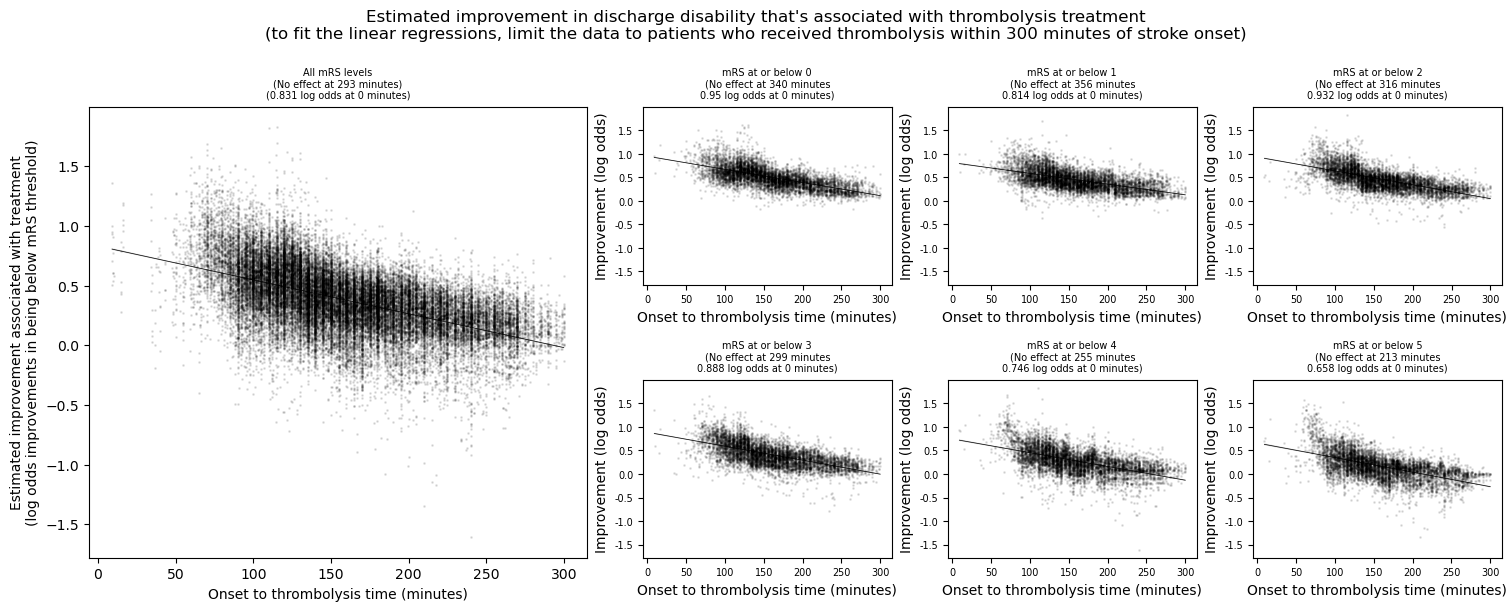

()

In [81]:
k = 0
df = df_shap_ivt_effect[df_shap_ivt_effect['kfold'] == k]
create_sns_mosaic_plot(df, filename_suffix="All patients", title_suffix="", max_treatment_time=300)

In [63]:
df

,onset_to_thrombolysis_time,ivt_shap_ivt_improvement,mRS_threshold,kfold
0,90.0,0.621093,0,0
1,183.0,0.482160,0,0
2,187.0,0.542623,0,0
3,232.0,0.361295,0,0
4,165.0,0.530196,0,0
...,...,...,...,...
6892,132.0,0.591075,5,0
6893,118.0,0.100885,5,0
6894,180.0,0.242682,5,0
6895,124.0,0.449061,5,0
